Berhasil membaca dataset!

--- 5 Baris Pertama Data ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Info Split Data ---
Jumlah Data Latih: 4930
Jumlah Data Uji  : 2113

HASIL EVALUASI: Logistic Regression
Akurasi: 78.28%

Confusion Matrix:
[[1381  171]
 [ 288  273]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.61      0.49      0.54       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113


HASIL EVALUASI: Decision Tree
Akurasi: 77.90%

Confusion Matrix:
[[1453   99]
 [ 368  193]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.94      0.86      1552
           1       0.66      0.34      0.45       561

    accuracy                           0.78      2113
   macro avg       0.73      0.64      0.66      2113
weighted avg       0.76      0.78      0.75      2113



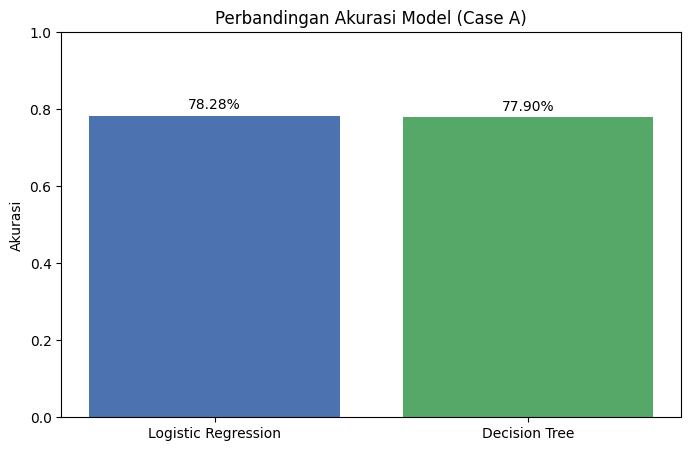

In [9]:
# ==========================================
# IDENTITAS MAHASISWA
# Nama      : Ridwan
# NIM       : 20123030
# Case      : A - Klasifikasi Tabular
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


try:
    df = pd.read_csv('/content/Telco-Customer-Churn')
    print("Berhasil membaca dataset!")
except FileNotFoundError:
    print("File tidak ditemukan! Pastikan nama file benar dan sudah diupload.")


print("\n--- 5 Baris Pertama Data ---")
display(df.head())

# PREPROCESSING

df_clean = df.drop(['customerID'], axis=1)

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].mean())

le = LabelEncoder()
for column in df_clean.select_dtypes(include=['object']).columns:
    df_clean[column] = le.fit_transform(df_clean[column])

selected_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService']
target = 'Churn'

X = df_clean[selected_features] # Data Fitur
y = df_clean[target]            # Data Target (Jawaban)

# 70% untuk Latihan, 30% untuk Ujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\n--- Info Split Data ---")
print(f"Jumlah Data Latih: {X_train.shape[0]}")
print(f"Jumlah Data Uji  : {X_test.shape[0]}")

# MODELING

# === 1: Logistic Regression (Baseline) ===
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train) # Proses belajar
y_pred_log = log_model.predict(X_test) # Proses ujian

# === 2: Decision Tree (Pembanding) ===
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train) # Proses belajar
y_pred_dt = dt_model.predict(X_test) # Proses ujian


# EVALUASI

def tampilkan_evaluasi(nama_model, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*20}")
    print(f"HASIL EVALUASI: {nama_model}")
    print(f"{'='*20}")
    print(f"Akurasi: {acc:.2%}") # Menampilkan dalam persen
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    return acc

# Menampilkan hasil kedua model
acc_log = tampilkan_evaluasi("Logistic Regression", y_test, y_pred_log)
acc_dt = tampilkan_evaluasi("Decision Tree", y_test, y_pred_dt)

# VISUALISASI PERBANDINGAN
models = ['Logistic Regression', 'Decision Tree']
accuracies = [acc_log, acc_dt]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#4c72b0', '#55a868'])
plt.ylim(0, 1)
plt.ylabel('Akurasi')
plt.title('Perbandingan Akurasi Model (Case A)')

# Menambahkan angka di atas batang chart
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom')

plt.show()